<a href="https://colab.research.google.com/github/anastasiakalyashova/python-ai-AnastasiaKalyashova/blob/main/week3e_ridge_elevation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ═══════════════════════════════════════════════════════
#  ЯЧЕЙКА 0. Подготовка данных (из week2b_read_csv.ipynb)
#  Запускать первой в каждом ноутбуке задания 3
# ═══════════════════════════════════════════════════════

# --- Параметры (изменять здесь) ----------------------
RADIUS_KM     = 300   # радиус соседства гор (для week3a)
TOP_N_ROCKS   = 10    # сколько топ-пород использовать
TOP_N_COMPLEX = 20    # сколько самых «сложных» гор брать
# -----------------------------------------------------

import os, pandas as pd, numpy as np
from itertools import combinations

# 1. Клонируем репозиторий (если ещё нет)
repo = "python-ai-AnastasiaKalyashova"
repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/anastasiakalyashova/python-ai-AnastasiaKalyashova.git
if os.getcwd() != repo_path:
    %cd {repo_path}

# 2. Читаем CSV
file_path = None
for root, dirs, files in os.walk("."):
    if "mountains.csv" in files:
        file_path = os.path.join(root, "mountains.csv")
        break
df = pd.read_csv(file_path)

# 3. Переименование столбцов
if "mountainLabel" in df.columns:
    df = df.rename(columns={
        "mountain":          "URL",
        "mountainLabel":     "mountain",
        "rockMaterialLabel": "rockMaterial",
        "elevationMeters":   "elevation",
    })

# 4. Нормализуем породы
df["rockMaterial"] = df["rockMaterial"].str.lower().str.strip()

# 🔧 ИСПРАВЛЕНИЕ: заменяем "lutite" на "пелит"
df["rockMaterial"] = df["rockMaterial"].replace("lutite", "пелит")

# 5. Парсим координаты
coords = df["coordinates"].str.extract(r'Point\(([^\s]+)\s+([^\s]+)\)')
df["lon"] = pd.to_numeric(coords[0], errors="coerce")
df["lat"] = pd.to_numeric(coords[1], errors="coerce")

# 6. df_unique — по одной строке на гору
df_unique = (
    df.groupby("URL")
    .agg(
        mountain   = ("mountain",     "first"),
        lon        = ("lon",          "first"),
        lat        = ("lat",          "first"),
        elevation  = ("elevation",    "first"),
        rock_count = ("rockMaterial", "nunique"),
        rocks      = ("rockMaterial", lambda x: list(x.unique())),
    )
    .reset_index()
)

# 7. df_clean — только физически возможные высоты
df_clean = df_unique[
    (df_unique.elevation >= 0) &
    (df_unique.elevation <= 8849)
].copy()

# 8. Топ пород по частоте (по df_clean)
top_rocks = (
    df[df["URL"].isin(df_clean["URL"])]
    ["rockMaterial"].value_counts()
    .head(TOP_N_ROCKS).index.tolist()
)

# 9. Co-occurrence матрица пород
pairs = []
for rocks in df_clean["rocks"]:
    clean = [r for r in rocks if r in top_rocks]
    pairs += list(combinations(sorted(set(clean)), 2))
cooc = (pd.DataFrame(pairs, columns=["r1", "r2"])
        .value_counts()
        .reset_index(name="count"))

print(f"✅ Длинный формат:    {len(df)} строк")
print(f"✅ Уникальных гор:    {len(df_unique)}")
print(f"✅ df_clean:          {len(df_clean)} гор (0–8849 м)")
print(f"✅ Топ-{TOP_N_ROCKS} пород:    {top_rocks}")
print(f"✅ Пар co-occurrence: {len(cooc)}")

/content/python-ai-AnastasiaKalyashova
✅ Длинный формат:    4431 строк
✅ Уникальных гор:    2915
✅ df_clean:          2914 гор (0–8849 м)
✅ Топ-10 пород:    ['известняк', 'песчаник', 'гранит', 'мергель', 'конгломерат', 'пелит', 'доломит', 'андезит', 'осадочная горная порода', 'базальт']
✅ Пар co-occurrence: 15


✅ Топ-8 пород: ['известняк', 'песчаник', 'гранит', 'мергель', 'конгломерат', 'пелит', 'доломит', 'андезит']
✅ Всего уникальных гор: 2914
   известняк                : n= 795, медиана=1117.0 м
   песчаник                 : n= 517, медиана= 891.0 м
   гранит                   : n= 321, медиана=2723.0 м
   мергель                  : n= 299, медиана= 731.0 м
   конгломерат              : n= 291, медиана= 983.0 м
   пелит                    : n= 230, медиана=2001.7 м
   доломит                  : n= 166, медиана= 987.5 м
   андезит                  : n= 147, медиана=2422.0 м



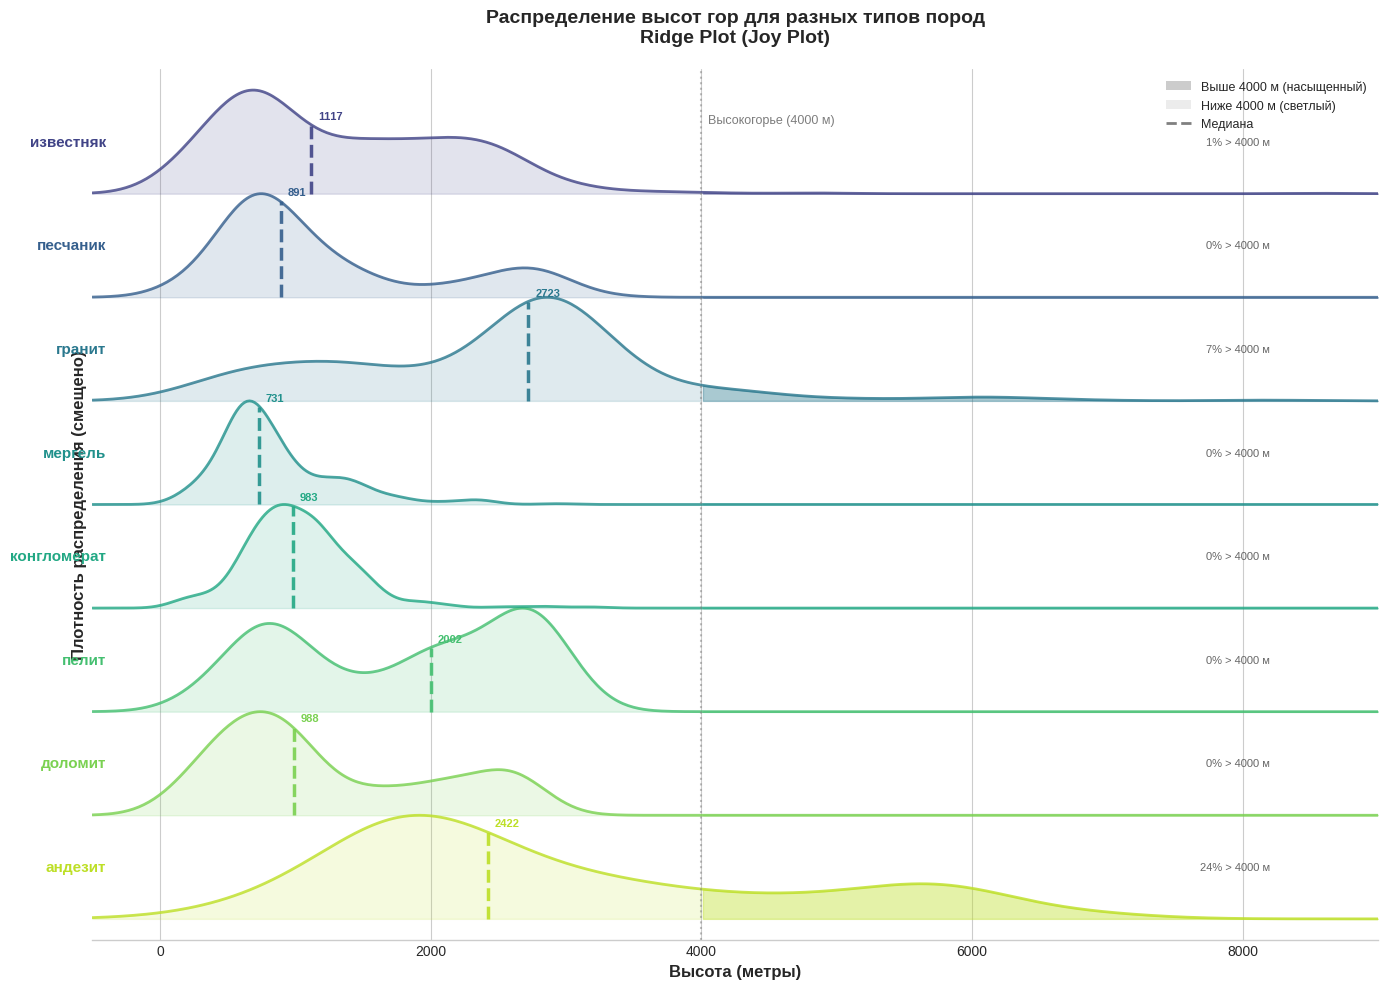


СТАТИСТИКА ДЛЯ ОПРЕДЕЛЕНИЯ САМОЙ ВЫСОКОГОРНОЙ ПОРОДЫ
     Порода  Кол-во гор  Медиана (м)  Средняя (м)  Доля >4000м (%)  Максимум (м)
    андезит         147      2422.00  2944.333556        24.489796       6962.00
     гранит         321      2723.00  2478.275958         6.853583       8163.00
  известняк         795      1117.00  1349.886451         0.503145       8586.00
   песчаник         517       891.00  1216.609009         0.000000       3328.00
    мергель         299       731.00   853.747157         0.000000       2936.00
конгломерат         291       983.00  1028.469244         0.000000       3193.00
      пелит         230      2001.65  1794.188261         0.000000       3143.45
    доломит         166       987.50  1242.926506         0.000000       2804.00


САМАЯ ВЫСОКОГОРНАЯ ПОРОДА: андезит
   • Доля гор выше 4000 м: 24.5%
   • Медианная высота: 2422 м
   • Средняя высота: 2944 м

ВОПРОС ДЛЯ АНАЛИЗА
Какая порода самая высокогорная — у которой наибольшая доля гор выше 

In [3]:
# ═══════════════════════════════════════════════════════════════════════
#  week3e_ridge_elevation.ipynb — Хребты вероятностей: ridge plot
#  Визуализация распределения высот для топ-8 пород
# ═══════════════════════════════════════════════════════════════════════

# --- 0. Подготовка данных ---
import os, pandas as pd, numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')  # Подавляем все предупреждения (опционально)

# Параметры
TOP_N_ROCKS = 8
RADIUS_KM = 300
TOP_N_COMPLEX = 20

# Клонируем репозиторий
repo = "python-ai-AnastasiaKalyashova"
repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/anastasiakalyashova/python-ai-AnastasiaKalyashova.git
if os.getcwd() != repo_path:
    %cd {repo_path}

# Читаем CSV
file_path = None
for root, dirs, files in os.walk("."):
    if "mountains.csv" in files:
        file_path = os.path.join(root, "mountains.csv")
        break
df = pd.read_csv(file_path)

# Переименование столбцов
if "mountainLabel" in df.columns:
    df = df.rename(columns={
        "mountain": "URL",
        "mountainLabel": "mountain",
        "rockMaterialLabel": "rockMaterial",
        "elevationMeters": "elevation",
    })

# Нормализуем породы
df["rockMaterial"] = df["rockMaterial"].str.lower().str.strip()
df["rockMaterial"] = df["rockMaterial"].replace("lutite", "пелит")

# Парсим координаты
coords = df["coordinates"].str.extract(r'Point\(([^\s]+)\s+([^\s]+)\)')
df["lon"] = pd.to_numeric(coords[0], errors="coerce")
df["lat"] = pd.to_numeric(coords[1], errors="coerce")

# Создаём df_unique — по одной строке на гору
df_unique = (
    df.groupby("URL")
    .agg(
        mountain=("mountain", "first"),
        lon=("lon", "first"),
        lat=("lat", "first"),
        elevation=("elevation", "first"),
        rock_count=("rockMaterial", "nunique"),
        rocks=("rockMaterial", lambda x: list(x.unique())),
    )
    .reset_index()
)

# Фильтруем по высоте (только реальные горы)
df_clean = df_unique[
    (df_unique.elevation >= 0) & (df_unique.elevation <= 8849)
].copy()

# Топ-8 пород по частоте (по уникальным горам)
rock_series = df_clean.explode("rocks")["rocks"]
top_rocks = rock_series.value_counts().head(TOP_N_ROCKS).index.tolist()

print(f"✅ Топ-{TOP_N_ROCKS} пород: {top_rocks}")
print(f"✅ Всего уникальных гор: {len(df_clean)}")

# Собираем высоты для каждой породы
rock_elevations = {}
rock_medians = {}

for rock in top_rocks:
    mask = df_clean["rocks"].apply(lambda x: rock in x)
    elevations = df_clean.loc[mask, "elevation"].values
    rock_elevations[rock] = elevations
    rock_medians[rock] = np.median(elevations)
    print(f"   {rock:25s}: n={len(elevations):4d}, медиана={rock_medians[rock]:6.1f} м")

print("\n" + "="*70)

# --- 1. Построение ridge plot (без эмодзи) ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 10))

# Параметры графика
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top_rocks)))
y_spacing = 0.25
y_offset = 0
x_range = np.linspace(-500, 9000, 500)
high_altitude = 4000

# Строим кривые снизу вверх
for i, (rock, color) in enumerate(zip(reversed(top_rocks), reversed(colors))):
    elevations = rock_elevations[rock]

    if len(elevations) > 1:
        # KDE
        kde = gaussian_kde(elevations, bw_method=0.3)
        density = kde(x_range)

        # Нормализация и смещение
        density_normalized = density / density.max() * y_spacing
        y_values = density_normalized + y_offset

        # Основная кривая
        ax.plot(x_range, y_values, color=color, linewidth=2, alpha=0.8)

        # Закраска выше 4000 м (насыщенная)
        high_mask = x_range >= high_altitude
        if np.any(high_mask):
            ax.fill_between(x_range[high_mask], y_offset, y_values[high_mask],
                           color=color, alpha=0.4)

        # Закраска ниже 4000 м (светлая)
        low_mask = x_range < high_altitude
        if np.any(low_mask):
            ax.fill_between(x_range[low_mask], y_offset, y_values[low_mask],
                           color=color, alpha=0.15)

        # Вертикальная линия медианы
        median_val = rock_medians[rock]
        median_idx = np.argmin(np.abs(x_range - median_val))
        median_y = y_values[median_idx]
        ax.vlines(median_val, y_offset, median_y,
                  colors=color, linewidth=2.5, linestyle='--', alpha=0.9)

        # Подпись медианы
        ax.text(median_val + 50, median_y + 0.01, f'{median_val:.0f}',
                fontsize=8, ha='left', va='bottom', color=color, fontweight='bold')

        # Название породы
        ax.text(-400, y_offset + y_spacing/2, rock,
                fontsize=11, ha='right', va='center', fontweight='bold', color=color)

        # Доля выше 4000 м
        high_percent = (elevations >= high_altitude).mean() * 100
        ax.text(8200, y_offset + y_spacing/2, f'{high_percent:.0f}% > {high_altitude} м',
                fontsize=8, ha='right', va='center', alpha=0.7)
    else:
        # Если данных мало
        ax.hlines(y_offset, elevations[0], elevations[0], color=color, linewidth=3)
        ax.text(-400, y_offset + y_spacing/2, rock,
                fontsize=11, ha='right', va='center', fontweight='bold')

    y_offset += y_spacing

# Настройка графика (убрали эмодзи из заголовка)
ax.set_xlim(-500, 9000)
ax.set_ylim(-0.05, y_offset + 0.05)
ax.set_xlabel('Высота (метры)', fontsize=12, fontweight='bold')
ax.set_ylabel('Плотность распределения (смещено)', fontsize=12, fontweight='bold')
ax.set_title('Распределение высот гор для разных типов пород\nRidge Plot (Joy Plot)',
             fontsize=14, fontweight='bold', pad=20)

ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Линия высокогорья
ax.axvline(x=high_altitude, color='gray', linestyle=':', alpha=0.5, linewidth=1.5)
ax.text(high_altitude + 50, y_offset - 0.08, f'Высокогорье ({high_altitude} м)',
        fontsize=9, alpha=0.6)

# Легенда
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='gray', alpha=0.4, label='Выше 4000 м (насыщенный)'),
    Patch(facecolor='gray', alpha=0.15, label='Ниже 4000 м (светлый)'),
    plt.Line2D([0], [0], color='gray', linestyle='--', linewidth=2, label='Медиана')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

# --- 2. Статистика для ответа на вопрос ---
print("\n" + "="*70)
print("СТАТИСТИКА ДЛЯ ОПРЕДЕЛЕНИЯ САМОЙ ВЫСОКОГОРНОЙ ПОРОДЫ")
print("="*70)

metrics = []
for rock in top_rocks:
    elevations = rock_elevations[rock]
    high_percent = (elevations >= 4000).mean() * 100
    metrics.append({
        'Порода': rock,
        'Кол-во гор': len(elevations),
        'Медиана (м)': rock_medians[rock],
        'Средняя (м)': np.mean(elevations),
        'Доля >4000м (%)': high_percent,
        'Максимум (м)': np.max(elevations)
    })

df_metrics = pd.DataFrame(metrics)
df_metrics = df_metrics.sort_values('Доля >4000м (%)', ascending=False)

print(df_metrics.to_string(index=False))

print("\n" + "="*70)
winner = df_metrics.iloc[0]
print(f"\nСАМАЯ ВЫСОКОГОРНАЯ ПОРОДА: {winner['Порода']}")
print(f"   • Доля гор выше 4000 м: {winner['Доля >4000м (%)']:.1f}%")
print(f"   • Медианная высота: {winner['Медиана (м)']:.0f} м")
print(f"   • Средняя высота: {winner['Средняя (м)']:.0f} м")
print("="*70)

# --- 3. Вопрос для анализа ---
print("\n" + "="*70)
print("ВОПРОС ДЛЯ АНАЛИЗА")
print("="*70)
print("Какая порода самая высокогорная — у которой наибольшая доля гор выше 4000 м?")
print("\nОТВЕТ:", winner['Порода'])
print("="*70)